In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import statsmodels.api as sm


In [3]:
np.random.seed(42)

n = 1000

data = pd.DataFrame({
    "user_id": range(n),
    "group": np.random.choice(["control", "treatment"], n),
    "prior_engagement": np.random.normal(50, 10, n)
})

data["watch_time"] = data["prior_engagement"] + \
    np.where(data["group"] == "treatment",
             np.random.normal(10, 5, n),
             np.random.normal(0, 5, n))

data.head()

,user_id,group,prior_engagement,watch_time
0,0,control,53.417560,52.265556
1,1,treatment,68.761708,86.569264
2,2,control,59.504238,63.955230
3,3,control,44.230963,49.407210
4,4,control,41.015853,31.784914


In [4]:
data.describe()

,user_id,prior_engagement,watch_time
count,1000.000000,1000.000000,1000.000000
mean,499.500000,50.401664,55.537216
std,288.819436,10.012925,12.059980
min,0.000000,21.037446,19.850272
25%,249.750000,43.749954,47.420959
50%,499.500000,50.366335,55.711199
75%,749.250000,56.815984,64.170068
max,999.000000,80.788808,90.260080


In [5]:
data.groupby("group")["watch_time"].mean()

group
control      50.425738
treatment    60.448245
Name: watch_time, dtype: float64

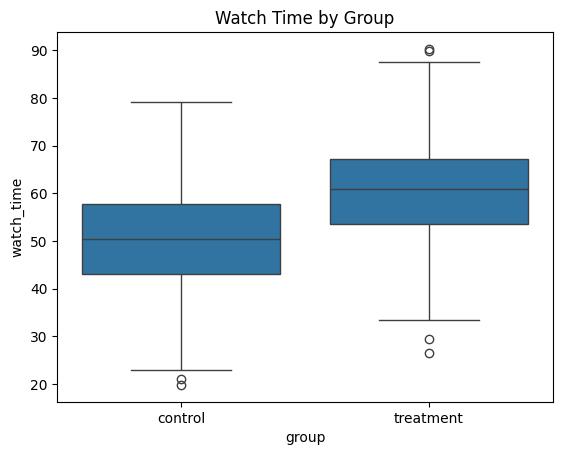

In [6]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.boxplot(x="group", y="watch_time", data=data)
plt.title("Watch Time by Group")
plt.show()

In [7]:
from scipy import stats

control = data[data["group"] == "control"]["watch_time"]
treatment = data[data["group"] == "treatment"]["watch_time"]

t_stat, p_value = stats.ttest_ind(treatment, control)

print("T-stat:", t_stat)
print("P-value:", p_value)

T-stat: 14.43715062467623
P-value: 4.7623574007846374e-43


In [ ]:
# Measuring the Causal Impact of a Recommendation Algorithm on User Engagement

In [8]:
data["treatment_flag"] = (data["group"] == "treatment").astype(int)

import statsmodels.api as sm

X = data[["treatment_flag", "prior_engagement"]]
X = sm.add_constant(X)
y = data["watch_time"]

model = sm.OLS(y, X).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:             watch_time   R-squared:                       0.834
Model:                            OLS   Adj. R-squared:                  0.834
Method:                 Least Squares   F-statistic:                     2511.
Date:                Mon, 30 Mar 2026   Prob (F-statistic):               0.00
Time:                        14:26:33   Log-Likelihood:                -3009.4
No. Observations:                1000   AIC:                             6025.
Df Residuals:                     997   BIC:                             6040.
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
const                0.9893      0.814  

In [9]:
# Measuring the Causal Impact of a Recommendation Algorithm on User Engagement

# Measuring the Causal Impact of a Recommendation Algorithm on User Engagement

## Business Problem

Streaming platforms rely heavily on recommendation systems to drive user engagement. 

This analysis evaluates whether a new recommendation algorithm increases user watch time compared to the existing system.

## Approach

To measure impact, we simulate an A/B test:

- Control group: Existing recommendation system
- Treatment group: New recommendation algorithm

We evaluate:
- Watch time differences
- Statistical significance (t-test)
- Causal impact using regression analysis controlling for prior engagement

## Data

The dataset includes:
- user_id
- group (control vs treatment)
- prior_engagement
- watch_time

Data is simulated to reflect user engagement behavior.

## Results

- The treatment group shows higher average watch time compared to control.
- A t-test indicates the difference is statistically significant (p < 0.001).
- Regression analysis estimates a causal increase of ~10 units in watch time after controlling for prior engagement.

These results suggest the new recommendation algorithm meaningfully improves user engagement.

## Business Recommendation

Based on the results, the new recommendation algorithm should be considered for full rollout.

Next steps:
- Validate results on real user segments
- Monitor long-term retention impact
- Test additional personalization improvements

## 🧪 A/B Testing

We compare average watch time between control and treatment groups using a t-test.

In [11]:
# Split control and treatment groups
control = data[data["group"] == "control"]["watch_time"]
treatment = data[data["group"] == "treatment"]["watch_time"]

# Perform t-test to compare groups
t_stat, p_value = stats.ttest_ind(treatment, control)

print("T-stat:", t_stat)
print("P-value:", p_value)

T-stat: 14.43715062467623
P-value: 4.7623574007846374e-43


In [12]:
data.groupby("group")["watch_time"].agg(["mean", "std", "count"])

,mean,std,count
group,,,
control,50.425738,11.423647,490
treatment,60.448245,10.524617,510


The treatment group not only shows higher average engagement but also consistent variability, indicating the effect is stable across users.